# 3.7 Weight Decay (L2 Regularization)

**Weight decay** is one of the most common techniques for fighting *overfitting*. Rather than limiting the *number* of features, it limits how *large* the weights can grow by adding a penalty on their size to the loss:

$$L(\mathbf{w}, b) + \frac{\lambda}{2}\lVert\mathbf{w}\rVert^2$$

- $\lambda \ge 0$ controls the regularization strength ($\lambda = 0$ recovers the original loss).
- Larger $\lambda$ → smaller weights → a simpler, smoother model.

Minimizing this penalized objective with minibatch SGD changes the ordinary weight update into

$$\mathbf{w} \leftarrow (1 - \eta\lambda)\,\mathbf{w} - \frac{\eta}{|\mathcal{B}|}\sum_{i \in \mathcal{B}} \mathbf{x}^{(i)}\left(\mathbf{w}^\top\mathbf{x}^{(i)} + b - y^{(i)}\right).$$

The second term is the usual gradient step; the new factor $(1-\eta\lambda)$ shrinks $\mathbf{w}$ toward zero *before* that step is applied — that shrinkage is where the name **weight decay** comes from. The bias $b$ is conventionally left out of the penalty, since penalizing it does little to curb overfitting.

Below we implement the same idea two ways: **from scratch**, and using PyTorch's **built-in** optimizer support.

In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

A quick sanity check on the update rule before touching real data: at a point where the data-fit gradient is exactly zero, a single SGD step with `weight_decay` should shrink a parameter by precisely the factor $(1-\eta\lambda)$ above — nothing more.

In [2]:
w_demo = nn.Parameter(torch.tensor([2.0]))                   # toy weight, starts at 2.0
opt = torch.optim.SGD([w_demo], lr=0.1, weight_decay=0.5)     # eta=0.1, lambda=0.5
w_demo.grad = torch.zeros_like(w_demo)                        # pretend the loss gradient is exactly 0 here
opt.step()                                                    # one update step
predicted = (1 - 0.1 * 0.5) * 2.0                             # (1 - eta*lambda) * w, per the update rule
print(f'w after one step: {w_demo.item():.4f}  (predicted (1-eta*lambda)*w = {predicted:.4f})')

w after one step: 1.9000  (predicted (1-eta*lambda)*w = 1.9000)


## 3.7.2 Generating Synthetic Data

To make overfitting easy to observe, we use a **high-dimensional** problem with **few** training points: 200 inputs but only 20 training examples. The ground-truth model has deliberately tiny weights ($0.01$) and bias ($0.05$):

$$y = 0.01 \sum_{i=1}^{200} x_i + 0.05 + \epsilon, \quad \epsilon \sim \mathcal{N}(0, 0.01^2)$$

With so few examples relative to the number of parameters, an unregularized model will happily memorize the noise.

In [3]:
class Data(d2l.DataModule):
    def __init__(self, num_train, num_val, num_inputs, batch_size):
        self.save_hyperparameters()          # store args as attributes (num_train, etc.)
        n = num_train + num_val              # total number of examples
        self.X = torch.randn(n, num_inputs)  # random inputs ~ N(0, 1)
        noise = torch.randn(n, 1) * 0.01     # small Gaussian noise
        # True model: small weights (0.01) and bias (0.05) — a linear ground truth
        w, b = torch.ones((num_inputs, 1)) * 0.01, 0.05
        self.y = torch.matmul(self.X, w) + b + noise   # labels y = Xw + b + noise

    def get_dataloader(self, train):
        # Pick the training slice or the validation slice by index
        i = slice(0, self.num_train) if \
        train else slice(self.num_train, None)
        
        return self.get_tensorloader([self.X, self.y], train, i)


## 3.7.3 Implementation from Scratch

Since minibatch SGD is our optimizer, adding weight decay only requires adding the squared $L_2$ penalty to the loss — the linear model and the squared-error loss itself are unchanged from ordinary linear regression.

### 3.7.3.1 The L2 Penalty

The penalty is half the squared $L_2$ norm of the weights:

$$\frac{1}{2}\lVert\mathbf{w}\rVert^2 = \frac{1}{2}\sum_i w_i^2$$

The factor of $\tfrac{1}{2}$ is a convention: it makes the derivative simply $\mathbf{w}$, keeping the gradient clean.

In [4]:
def l2_penalty(w):
    return (w ** 2).sum() / 2 

### 3.7.3.2 Implementing From Scratch

We subclass the plain linear-regression model and override only `loss`, adding $\lambda \cdot \frac{1}{2}\lVert\mathbf{w}\rVert^2$ to the usual squared error. Everything else — parameters, forward pass, optimizer — is inherited unchanged.

In [5]:
class WeightDecayScratch(d2l.LinearRegressionScratch):
    def __init__(self, num_inputs, lambd, lr, sigma=0.01):
        super().__init__(num_inputs, lr, sigma)  # init base model (w, b, lr)
        self.save_hyperparameters()              # store lambd (L2 strength), etc.

    def loss(self, y_hat, y):
        # Total loss = squared-error loss + λ * L2 penalty on the weights
        return (super().loss(y_hat, y) +
                self.lambd * l2_penalty(self.w))

### Setting Up Training

We build the dataset and trainer once, then wrap model creation and fitting in a helper `train_scratch(lambd)` so we can compare regularization strengths side by side. The printed **L2 norm of `w`** is our quick diagnostic — it should shrink as $\lambda$ grows.

In [6]:
# High-dimensional (200 inputs) but tiny training set (20) → easy to overfit
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
trainer = d2l.Trainer(max_epochs=10)   # runs the training loop for 10 epochs

def train_scratch(lambd):
    # Build the model with a given weight-decay strength λ
    model = WeightDecayScratch(num_inputs=200, lambd=lambd, lr=0.01)
    model.board.yscale = 'log'          # plot loss on a log scale (easier to read)
    trainer.fit(model, data)            # train on data (fits train, evaluates val)
    # Report how large the learned weights are — smaller means stronger regularization
    # .detach(): w still requires_grad after training, so drop it from the graph before float()
    print('L2 norm of w:', float(l2_penalty(model.w.detach())))

### 3.7.3.3 Training Without Regularization

Running with `lambd=0` disables the penalty entirely. With only 20 examples and 200 parameters, the model overfits: training loss keeps dropping while validation loss stalls, and the weights grow large (big L2 norm).

L2 norm of w: 0.010851790197193623


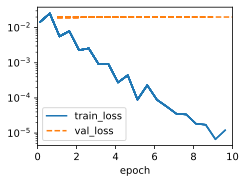

In [7]:
train_scratch(0)   # no weight decay → overfitting, large ‖w‖

### 3.7.3.4 Training With Weight Decay

Now with `lambd=3` the penalty is active. The validation loss improves and the L2 norm of `w` drops noticeably — the regularization is shrinking the weights and curbing overfitting.

L2 norm of w: 0.0012927064672112465


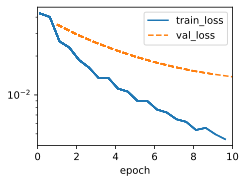

In [8]:
train_scratch(3)   # weight decay on → smaller ‖w‖, less overfitting

## 3.7.4 Concise Implementation

Because $L_2$ regularization is so common, deep-learning frameworks fold it directly into the optimizer via a `weight_decay` argument — no need to touch the loss by hand. We split the parameters into **two groups** so decay applies to the **weights only**, not the bias (the bias doesn't drive overfitting and is conventionally left un-penalized).

In [9]:
class WeightDecay(d2l.LinearRegression):
    def __init__(self, wd, lr):
        super().__init__(lr)         # init base model (net, lr) from parent
        self.save_hyperparameters()  # store wd (weight-decay strength) and lr
        self.wd = wd

    def configure_optimizers(self):
        # Apply weight decay to the weights only, NOT to the bias
        return torch.optim.SGD([
            {'params': self.net.weight, 'weight_decay': self.wd},  # decayed
            {'params': self.net.bias}],                            # not decayed
            lr=self.lr)


### Training the Concise Model

Training on the same data with `wd=3`, weight decay is again clearly visible in the **L2 norm of `w`** — but don't expect it to closely match the from-scratch result at $\lambda=3$. The two aren't numerically equivalent: `d2l.LinearRegression.loss` uses `nn.MSELoss()`, the *plain* mean of $(\hat y - y)^2$, while our scratch `loss` uses half of that. For the same nominal $\lambda$/`wd`, this makes the data-fit gradient in the concise model twice as large relative to the decay term, so it regularizes visibly less aggressively than the scratch version at the same $\lambda$ — a reminder that a hand-written $\lambda\cdot\frac{1}{2}\lVert\mathbf{w}\rVert^2$ penalty and the optimizer's `weight_decay` only line up exactly once the loss scaling matches.

L2 norm of w: 0.012503951787948608


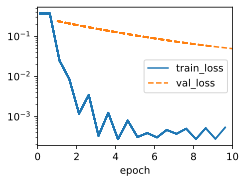

In [10]:
model = WeightDecay(wd=3, lr=0.01)   # concise model with weight decay λ=3
model.board.yscale = 'log'           # plot loss on a log scale (easier to read)
trainer.fit(model, data)             # train on the same overfitting-prone data

# get_w_b() returns (weight, bias); [0] grabs the weight to measure its L2 norm
print('L2 norm of w:', float(l2_penalty(model.get_w_b()[0])))


## 3.7.5 Summary

- **Weight decay** ($L_2$ regularization) adds $\frac{\lambda}{2}\lVert\mathbf{w}\rVert^2$ to the loss. Under SGD this turns into the update $\mathbf{w} \leftarrow (1-\eta\lambda)\mathbf{w} - \eta \cdot (\text{gradient of the loss})$ — the weights shrink toward zero at every step, which is where the name comes from.
- $\lambda = 0$ recovers plain regression; larger $\lambda$ trades training fit for a simpler, lower-variance model.
- On our synthetic 200-feature, 20-example problem, **no decay overfits**: training loss keeps falling while validation loss stalls, and $\lVert\mathbf{w}\rVert$ stays large. **Decay with $\lambda=3$** noticeably shrinks $\lVert\mathbf{w}\rVert$ and improves the validation loss — see the "L2 norm of w" values printed above.
- **From scratch**, the penalty is added directly inside `loss`; **concisely**, PyTorch's optimizer takes care of it via a `weight_decay` argument. The two are not numerically identical, though: `nn.MSELoss` (used by the concise model) omits the $\frac{1}{2}$ factor our scratch loss includes, so the same nominal $\lambda$/`wd` regularizes somewhat less aggressively in the concise version.
- The **bias is conventionally left unregularized**: split the optimizer's parameter groups so `weight_decay` only applies to the weights.